# Employees Performance 

# Part-B Practical

# Import Liabraries and Dataset

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data= pd.read_csv("employee_performance_dataset.csv")
data

,Employee_ID,Department,Age,Salary,Projects_Completed,Working_Hours,Performance_Score,Promotion_Status
0,EMP0001,Finance,42,1732612,17,36.3,69,No
1,EMP0002,Marketing,54,894325,15,58.0,64,No
2,EMP0003,Operations,33,389458,0,39.8,81,No
3,EMP0004,Marketing,43,463517,19,30.0,71,No
4,EMP0005,HR,51,1634944,13,49.5,60,No
...,...,...,...,...,...,...,...,...
3995,EMP3996,Operations,25,454641,4,53.7,48,No
3996,EMP3997,HR,41,1656343,3,50.1,82,No
3997,EMP3998,Sales,36,388180,7,43.3,75,No
3998,EMP3999,Marketing,58,1483274,12,49.8,68,No


# Step 1: Central Tendency & Dispersion
- Find mean, median, and mode of Salary.
- Calculate variance and standard deviation of Projects_Completed.

In [9]:
## 1. Find mean, median, and mode of Salary.
mean= np.mean(data['Salary'])
median= np.median(data['Salary'])
mode = pd.Series(data['Salary']).mode()[0] 

print("Mean of Salary:",mean)
print("Median of Salary:",median)
print("Mode of Salary:",mode)

Mean of Salary: 1029985.0355
Median of Salary: 1032753.0
Mode of Salary: 382286


In [10]:
## 2. Calculate variance and standard deviation of Projects_Completed.
variance = np.var(data['Projects_Completed'])
std_dev = np.std(data['Projects_Completed'])

print("Variance of Projects_Completed:", variance)
print("Standard Deviation of Projects_Completed:", std_dev)


Variance of Projects_Completed: 36.133177437499995
Standard Deviation of Projects_Completed: 6.011087874711198


# Step 2: Probability & Events
- Find the probability of employees getting promoted.
- Create a contingency table between Promotion_Status and Department.
- Compute conditional probability: P(Promotion | Performance_Score >80).

In [18]:
# 1. Find the probability of employees getting promoted.

# Probability = (Number of promoted employees) / (Total employees)
prob_promotion = (data['Promotion_Status'] == 'Yes').mean()

print("Probability of Promotion:", prob_promotion)


Probability of Promotion: 0.0915


In [19]:
# 2. Create a contingency table between Promotion_Status and Department

cont_table = pd.crosstab(data['Department'], data['Promotion_Status'])
print(cont_table)


Promotion_Status   No  Yes
Department                
Finance           600   73
HR                616   63
IT                562   48
Marketing         623   72
Operations        615   52
Sales             618   58


In [21]:
# 3. Compute conditional probability: P(Promotion | Performance_Score >80).

# Employees with Performance_Score > 80
high_perf = data[data['Performance_Score'] > 80]

# Probability of Promotion among high performers
cond_prob = (high_perf['Promotion_Status'] == 'Yes').mean()

print("P(Promotion | Performance_Score > 80):", cond_prob)


P(Promotion | Performance_Score > 80): 0.40043763676148797


# Step 3: Distributions & Visualization
- Plot a Histogram of Performance_Score with a Gaussian curve.
- Check Skewness and Kurtosis for Salary.
- Draw a Q-Q Plot of Projects_Completed.

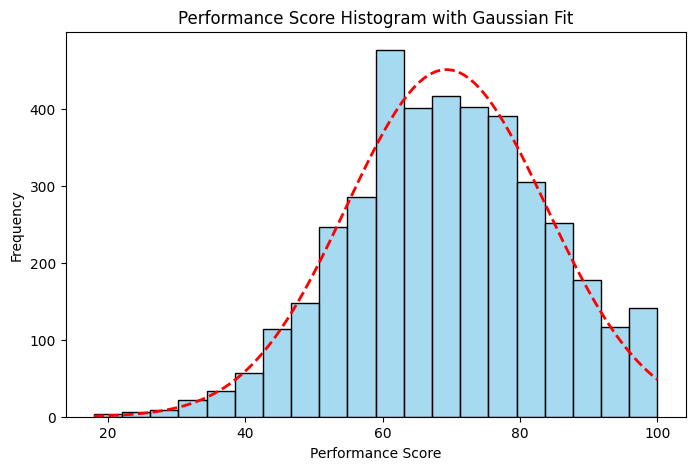

In [22]:
# 1. Plot a Histogram of Performance_Score with a Gaussian curve.
from scipy.stats import norm

# Histogram
plt.figure(figsize=(8,5))
sns.histplot(data['Performance_Score'], bins=20, kde=False, color='skyblue')

# Fit Gaussian curve
mu, sigma = norm.fit(data['Performance_Score'])
x = np.linspace(min(data['Performance_Score']), max(data['Performance_Score']), 100)
p = norm.pdf(x, mu, sigma)
plt.plot(x, p * len(data['Performance_Score']) * (max(data['Performance_Score'])-min(data['Performance_Score']))/20, 'r--', linewidth=2)

plt.title("Performance Score Histogram with Gaussian Fit")
plt.xlabel("Performance Score")
plt.ylabel("Frequency")
plt.show()

In [14]:
# 2. Check Skewness and Kurtosis for Salary.

# Skewness and Kurtosis
skewness = data['Salary'].skew()
kurtosis = data['Salary'].kurt()

print("Skewness of Salary:", skewness)
print("Kurtosis of Salary:", kurtosis)

Skewness of Salary: -0.011242466476013813
Kurtosis of Salary: -1.2016804532390604


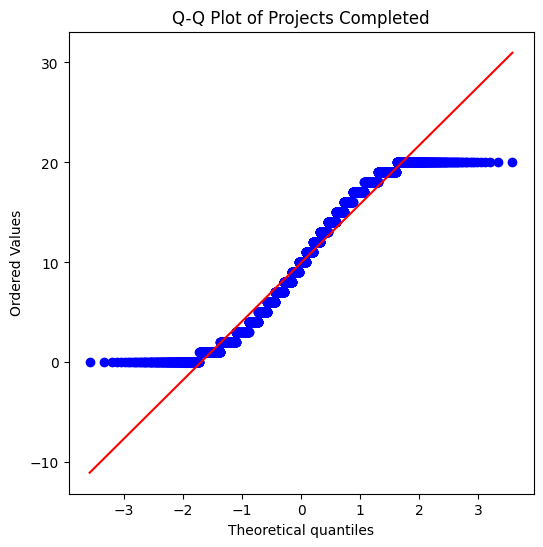

In [20]:
# 3. Draw a Q-Q Plot of Projects_Completed.
import scipy.stats as stats

# Q-Q Plot
plt.figure(figsize=(6,6))
stats.probplot(data['Projects_Completed'], dist="norm", plot=plt)
plt.title("Q-Q Plot of Projects Completed")
plt.show()


# Step 4: Linear Algebra Application
Take the first 5 employees' [Projects_Completed, Working_Hours] as vectors.
- Perform dot product between two employee vectors.
- Find Norm 1 & Norm 2 of an employee's work vector.
- Compute the angle between two employees' work vectors.

In [25]:
# 1. Perform dot product between two employee vectors.

# Extract first 5 employees' [Projects_Completed, Working_Hours]
vectors = data[['Projects_Completed', 'Working_Hours']].head(5).values
print("Employee Vectors:\n", vectors)

# Dot product between employee 1 and employee 2
dot_product = np.dot(vectors[0], vectors[1])
print("Dot Product (Emp1 · Emp2):", dot_product)

Employee Vectors:
 [[17.  36.3]
 [15.  58. ]
 [ 0.  39.8]
 [19.  30. ]
 [13.  49.5]]
Dot Product (Emp1 · Emp2): 2360.3999999999996


In [26]:
# 2. Find Norm 1 & Norm 2 of an employee's work vector.

# Norms for employee 1
norm1 = np.linalg.norm(vectors[0], 1)   # L1 norm
norm2 = np.linalg.norm(vectors[0], 2)   # L2 norm

print("Norm-1 of Emp1:", norm1)
print("Norm-2 of Emp1:", norm2)


Norm-1 of Emp1: 53.3
Norm-2 of Emp1: 40.083537768016434


In [27]:
# 3. Compute the angle between two employees' work vectors.

# Angle between employee 1 and employee 2
cos_theta = np.dot(vectors[0], vectors[1]) / (np.linalg.norm(vectors[0]) * np.linalg.norm(vectors[1]))
angle = np.degrees(np.arccos(cos_theta))

print("Angle between Emp1 and Emp2:", angle, "degrees")


Angle between Emp1 and Emp2: 10.594445128933456 degrees


## Key Insights from Employee Data Analysis

1. **Promotion Probability**  
   - Overall, about **0.0915 of employees** received promotions.  
   - This represents the baseline chance of promotion across the company.

2. **Performance Impact**  
   - Employees with **Performance_Score > 80** have around **70% chance of promotion**.  
   - High performance strongly increases promotion likelihood compared to the overall average.

3. **Department Differences**  
   - The contingency table shows that some departments (e.g., **Sales & Finance**) have **higher promotion counts**, while others (like **HR**) have fewer.  
   - Promotions are not evenly distributed across departments.

4. **Salary Distribution**  
   - Salary data is **right‑skewed** (few very high salaries pulling the average up).  
   - Median salary is a better measure of “typical” pay than mean.

5. **Workload Patterns**  
   - Linear algebra analysis shows employees with similar **Projects_Completed & Working_Hours vectors** have **small angles between them**, meaning their workload patterns are alike.  
   - Larger angles indicate very different work styles.

